In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [31]:
EXCEL_PATH = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\hasil_ekstraksi_fitur.xlsx' 

df = pd.read_excel(EXCEL_PATH)

print(f"Total data pasien: {len(df)}")
display(df.head())

Total data pasien: 211


,Country,Subject_ID,Age,Gender,mean_R,mean_G,mean_B,mean_L,mean_a,mean_b,mean_H,mean_S,mean_V,Hemoglobin,Anemia_Class
0,India,1,29,M,165.681334,82.346387,124.941774,118.559390,166.313710,124.941774,166.367962,130.298180,165.700354,12.2,2
1,India,2,36,F,159.608875,105.623553,119.549809,130.963319,154.832061,119.549809,160.096852,89.443007,160.550162,8.0,1
2,India,3,30,F,142.347389,81.613713,122.984434,108.931662,157.473051,122.984434,164.515150,112.148609,142.947018,10.7,1
3,India,4,39,F,172.217661,131.992063,115.307618,152.968773,149.983883,115.307618,150.293604,71.055925,178.894736,8.3,1
4,India,5,29,F,152.483330,82.745516,123.574996,113.115925,160.959679,123.574996,165.402269,118.849228,152.626490,7.8,0


In [32]:
df['Gender'] = df['Gender'].map({'M': 1, 'F': 0, 'Male': 1, 'Female': 0})

# hapus baris yang ga punya data
df = df.dropna(subset=['Age', 'Gender', 'Hemoglobin'])

print(f"Total data pasien setelah dibersihkan: {len(df)}")

Total data pasien setelah dibersihkan: 211


In [33]:
#feature_columns = ['Age', 'Gender', 'mean_R', 'mean_G', 'mean_B', 'mean_L', 'mean_a', 'mean_b', 'mean_H', 'mean_S', 'mean_V', 'Anemia_Class']
#feature_columns = ['Gender', 'mean_a', 'mean_B', 'mean_b', 'mean_S', 'mean_R']
feature_columns = ['Age', 'Gender', 'mean_R', 'mean_G', 'mean_B', 'mean_L', 'mean_a', 'mean_b', 'mean_H', 'mean_S', 'mean_V']

X = df[feature_columns]
y = df['Hemoglobin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Jumlah data untuk Training: {len(X_train)}')
print(f'Jumlah data untuk Testing:  {len(X_test)}')

Jumlah data untuk Training: 147
Jumlah data untuk Testing:  64


In [34]:
# `StandardScaler` akan menormalisasi seluruh rentang angka (termasuk Umur dan Warna) agar setara dan SVR bisa belajar dengan maksimal.

'''
models = {
    'MLR': make_pipeline(StandardScaler(), LinearRegression()),
    'SVR': make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1.0, gamma='scale')),
    'Random Forest': make_pipeline(StandardScaler(), RandomForestRegressor(max_depth=4,n_estimators=20, random_state=42)),
    'Gradient Boosting': make_pipeline(StandardScaler(), GradientBoostingRegressor(max_depth=4,learning_rate=0.1, n_estimators=20, random_state=42))
}
'''

model_params = {
    'MLR': {},
    'SVR': {
        'kernel': 'rbf', 
        'C': 1.0, 
        'gamma': 'scale'
    },
    'Random Forest': {
        'max_depth': 4, 
        'n_estimators': 20, 
        'random_state': 42
    },
    'Gradient Boosting': {
        'max_depth': 4, 
        'learning_rate': 0.1, 
        'n_estimators': 20, 
        'random_state': 42
    }
}

# =====================================================================
# 2. Inisialisasi Model dengan Pipeline (Menggunakan parameter di atas)
# =====================================================================
models = {
    'MLR': make_pipeline(StandardScaler(), LinearRegression(**model_params['MLR'])),
    'SVR': make_pipeline(StandardScaler(), SVR(**model_params['SVR'])),
    'Random Forest': make_pipeline(StandardScaler(), RandomForestRegressor(**model_params['Random Forest'])),
    'Gradient Boosting': make_pipeline(StandardScaler(), GradientBoostingRegressor(**model_params['Gradient Boosting']))
}

# =====================================================================
# 3. Membuat Tabel Konfigurasi (Otomatis membaca dari variabel)
# =====================================================================
param_strings = []
for name, params in model_params.items():
    if not params:
        param_strings.append('Default')
    else:
        # Menggabungkan key dan value menjadi string, contoh: "max_depth=4, n_estimators=20"
        param_str = ', '.join([f"{k}={repr(v)}" for k, v in params.items()])
        param_strings.append(param_str)

param_summary = {
    'Nama Model': ['Multiple Linear Regression (MLR)', 'Support Vector Regression (SVR)', 'Random Forest', 'Gradient Boosting'],
    'Hyperparameter yang Digunakan': param_strings
}

df_parameters = pd.DataFrame(param_summary)
df_parameters.index = np.arange(1, len(df_parameters) + 1)

print("=== TABEL KONFIGURASI PARAMETER MODEL ===")
display(df_parameters)

=== TABEL KONFIGURASI PARAMETER MODEL ===


,Nama Model,Hyperparameter yang Digunakan
1,Multiple Linear Regression (MLR),Default
2,Support Vector Regression (SVR),"kernel='rbf', C=1.0, gamma='scale'"
3,Random Forest,"max_depth=4, n_estimators=20, random_state=42"
4,Gradient Boosting,"max_depth=4, learning_rate=0.1, n_estimators=2..."


In [35]:
results = {}
predictions_dict = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    # predict
    y_pred = model.predict(X_test)
    predictions_dict[name] = y_pred 
    
    #mse
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MSE': mse, 'MAE (Error g/dL)': mae, 'R2 Score': r2}

results_df = pd.DataFrame(results).T
print("PERBANDINGAN PERFORMA MODEL")
display(results_df.sort_values(by='MAE (Error g/dL)'))

PERBANDINGAN PERFORMA MODEL


,MSE,MAE (Error g/dL),R2 Score
SVR,2.115819,1.103242,0.567194
Random Forest,2.229591,1.134435,0.543921
Gradient Boosting,2.281737,1.154470,0.533255
MLR,2.376234,1.223634,0.513925


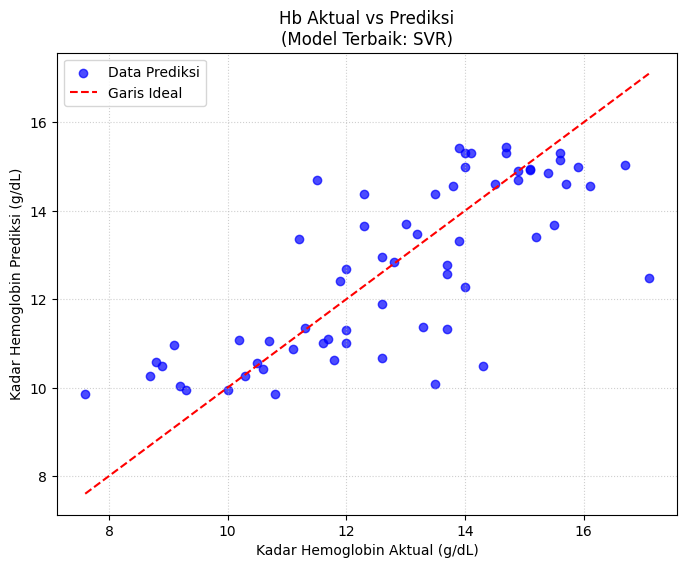

In [36]:
#cell buat visualisasi
best_model_name = results_df['MAE (Error g/dL)'].idxmin()
best_y_pred = predictions_dict[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_y_pred, alpha=0.7, color='blue', label='Data Prediksi')

min_val = min(min(y_test), min(best_y_pred))
max_val = max(max(y_test), max(best_y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')

plt.title(f'Hb Aktual vs Prediksi\n(Model Terbaik: {best_model_name})')
plt.xlabel('Kadar Hemoglobin Aktual (g/dL)')
plt.ylabel('Kadar Hemoglobin Prediksi (g/dL)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [37]:
#save model .pkl
best_model = models[best_model_name]

save_dir = '../models/weights/'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'hb_model_11features.pkl') 

joblib.dump(best_model, save_path)

print(f'\nweight sudah tersimpan di: {save_path}')


weight sudah tersimpan di: ../models/weights/hb_model_11features.pkl


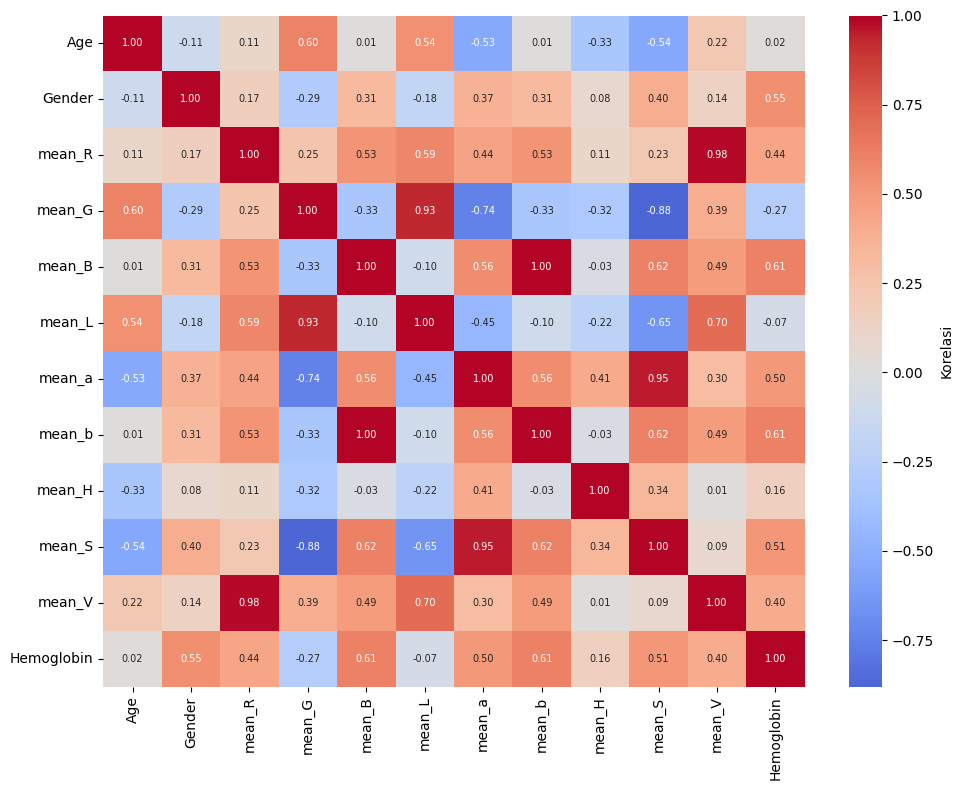

'\n# Memvisualisasikan korelasi khusus terhadap Hemoglobin\nsns.heatmap(correlation_matrix[[\'Hemoglobin\']].sort_values(by=\'Hemoglobin\', ascending=False), \n            annot=True, cmap=\'coolwarm\', vmin=-1, vmax=1)\nplt.title(\'Korelasi Pearson (PCC) terhadap Hemoglobin\')#Mendekati 1 atau -1 berarti sangat berpengaruh\nplt.show()\n\n# =========================================================\n# 2. Random Forest Feature Importance\n# =========================================================\nrf_selector = RandomForestRegressor(max_depth=4, n_estimators=20, random_state=42)\nrf_selector.fit(X_train, y_train)\n\nimportances_rf = rf_selector.feature_importances_\nindices_rf = np.argsort(importances_rf)[::-1] \n\nplt.figure(figsize=(10, 6))\nplt.title("2. Tingkat Kepentingan Fitur (Berdasarkan Random Forest)")\nplt.bar(range(X_train.shape[1]), importances_rf[indices_rf], align="center", color=\'skyblue\')\nplt.xticks(range(X_train.shape[1]), [feature_columns[i] for i in indices_rf], r

In [38]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

#Pearson Correlation Coefficient (PCC)
plt.figure(figsize=(10, 8))
#correlation_matrix = df[feature_columns + ['Hemoglobin']].corr(method='pearson')

correlation_matrix = df[feature_columns + ['Hemoglobin']].corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, cbar_kws={'label': 'Korelasi'}, annot_kws={'fontsize': 7})

#ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

'''
# Memvisualisasikan korelasi khusus terhadap Hemoglobin
sns.heatmap(correlation_matrix[['Hemoglobin']].sort_values(by='Hemoglobin', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi Pearson (PCC) terhadap Hemoglobin')#Mendekati 1 atau -1 berarti sangat berpengaruh
plt.show()

# =========================================================
# 2. Random Forest Feature Importance
# =========================================================
rf_selector = RandomForestRegressor(max_depth=4, n_estimators=20, random_state=42)
rf_selector.fit(X_train, y_train)

importances_rf = rf_selector.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1] 

plt.figure(figsize=(10, 6))
plt.title("2. Tingkat Kepentingan Fitur (Berdasarkan Random Forest)")
plt.bar(range(X_train.shape[1]), importances_rf[indices_rf], align="center", color='skyblue')
plt.xticks(range(X_train.shape[1]), [feature_columns[i] for i in indices_rf], rotation=45)
plt.ylabel('Skor Kepentingan')
plt.tight_layout()
plt.show()

# =========================================================
# 3. Gradient Boosting Feature Importance
# =========================================================
gb_selector = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_selector.fit(X_train, y_train)

importances_gb = gb_selector.feature_importances_
indices_gb = np.argsort(importances_gb)[::-1]

plt.figure(figsize=(10, 6))
plt.title("3. Tingkat Kepentingan Fitur (Berdasarkan Gradient Boosting)")
plt.bar(range(X_train.shape[1]), importances_gb[indices_gb], align="center", color='lightgreen')
plt.xticks(range(X_train.shape[1]), [feature_columns[i] for i in indices_gb], rotation=45)
plt.ylabel('Skor Kepentingan')
plt.tight_layout()
plt.show()

# =========================================================
# 4. SVR Feature Importance (Menggunakan Permutation Importance)
# =========================================================
# SVR sangat sensitif terhadap skala data, jadi kita wajib menggunakan StandardScaler
svr_selector = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1.0, gamma='scale'))
svr_selector.fit(X_train, y_train)

# Menghitung Permutation Importance
# n_repeats=10 berarti setiap fitur akan diacak 10 kali untuk melihat rata-rata penurunannya
result_svr = permutation_importance(svr_selector, X_train, y_train, n_repeats=10, random_state=42)

importances_svr = result_svr.importances_mean
indices_svr = np.argsort(importances_svr)[::-1]

plt.figure(figsize=(10, 6))
plt.title("4. Tingkat Kepentingan Fitur (Berdasarkan SVR - Permutation Importance)")
plt.bar(range(X_train.shape[1]), importances_svr[indices_svr], align="center", color='salmon')
plt.xticks(range(X_train.shape[1]), [feature_columns[i] for i in indices_svr], rotation=45)
plt.ylabel('Rata-rata Penurunan Akurasi Model')
plt.tight_layout()
plt.show()'''

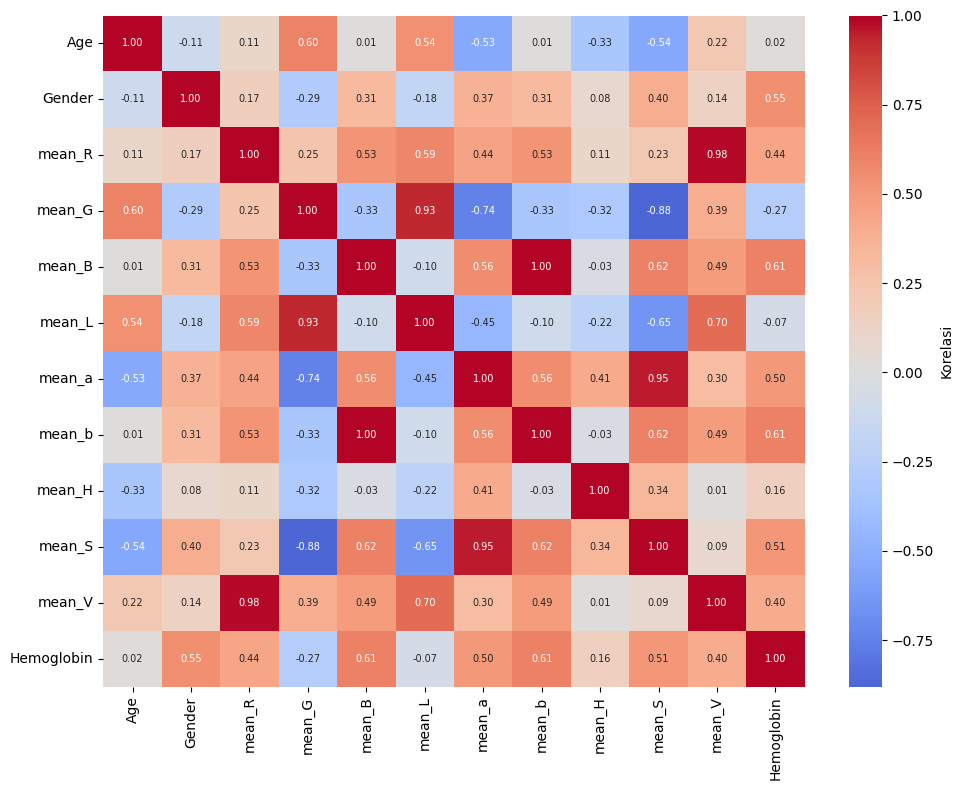

In [39]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

#Pearson Correlation Coefficient (PCC)
plt.figure(figsize=(10, 8))
#correlation_matrix = df[feature_columns + ['Hemoglobin']].corr(method='pearson')

correlation_matrix = df[feature_columns + ['Hemoglobin']].corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, cbar_kws={'label': 'Korelasi'}, annot_kws={'fontsize': 7})

#ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()